In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

Global Mars Parameters

In [ ]:
mars_mu = 4.2828e13
mars_radius = 3396000.0

Atmosphere Function

In [ ]:
def mars_atmosphere_density(altitude):
    """
    Calculates the atmospheric density at a given altitude above Mars.

    Parameters
    ----------
    altitude : float
        Altitude above the Martian surface in meters.

    Returns
    -------
    float
        Atmospheric density in kg/m³.
    """

    if altitude >= 130000:

        return 0.0

    elif altitude >= 40000:

        return (3.7e-4 * np.exp(-1.371e-4 * (altitude - 40000)))

    elif altitude >= 20000:

        return (2.8e-3 * np.exp(-1.012e-4 * (altitude - 20000)))

    elif altitude >= 0:

        return (1.417e-2 * np.exp(-0.8109e-4 * altitude))

    else:
        # Below the surface.
        # Prevents None from ever being returned.
        return 0

In [15]:
# ============================================================
# AEROCAPTURE SWEEP FUNCTION
# ============================================================

def run_aerocapture(
    vehicle_ballistic_coefficient,
    initial_gamma_deg
):


    # --------------------------------------------------------
    # Vehicle parameters
    # --------------------------------------------------------

    vehicle_mass = 10000.0
    vehicle_reference_area = 20.0
    vehicle_lift_to_drag = 1.0
    vehicle_nose_radius = 3.5

    def spacecraft_dynamics(time, state, bank_angle):

        altitude = state[0]
        downrange = state[1]
        velocity = state[2]
        gamma = state[3]
        theta = state[4]

        density = mars_atmosphere_density(altitude)

        radius = mars_radius + altitude

        gravity = mars_mu / radius**2

        drag_force = (
            0.5
            * density
            * velocity**2
            * vehicle_mass
            / vehicle_ballistic_coefficient
        )

        lift_force = drag_force * vehicle_lift_to_drag

        altitude_rate = velocity * np.sin(gamma)

        downrange_rate = (
            mars_radius / radius
        ) * velocity * np.cos(gamma)

        velocity_rate = (
            -drag_force / vehicle_mass
            - gravity * np.sin(gamma)
        )

        gamma_rate = (
            (
                lift_force
                * np.cos(bank_angle)
            )
            / (vehicle_mass * velocity)
            +
            (
                (
                    velocity**2 / radius
                )
                - gravity
            )
            * np.cos(gamma)
            / velocity
        )

        theta_rate = (
            velocity
            * np.cos(gamma)
            / radius
        )

        return [
            altitude_rate,
            downrange_rate,
            velocity_rate,
            gamma_rate,
            theta_rate
        ]
    
    # THERMAL FUNCTIONS

    # Radiative heat flux correlation for Mars

    # Below 6km/s model 
    def mars_slow(V, rho, Rn):
        """
        Low-speed Mars radiative heating correlation (Eq. 7)

        ---------

        Parameters
        V : Freestream velocity [km/s]
        rho : Freestream density [kg/m^3]
        Rn : Effective nose radius [m]

        Returns
        q_rad : Radiative heat flux [W/m^2]

        """
        L = np.log(rho)

        f = (
            # Constant + first order
            -6.0539
            + 4.6540*V
            - 0.3880*L
            + 0.2274*Rn

            # Second order
            - 0.3080*V**2
            - 0.1430*V*L
            - 0.0914*V*Rn
            - 0.1584*L**2
            - 0.0856*L*Rn
            - 0.0573*Rn**2

            # Third order
            - 0.1212*V**3
            + 0.0935*V**2*L
            + 0.0371*V**2*Rn
            + 5.7929e-3*V*L**2
            - 7.4995e-4*V*Rn**2
            + 3.9562e-4*V*L*Rn
            - 9.3175e-3*L**3
            - 2.8918e-3*L**2*Rn
            + 4.0269e-3*L*Rn**2
            + 4.3082e-3*Rn**3

            # Fourth order
            + 0.0164*V**4
            - 6.6590e-3*V**3*L
            - 2.8111e-3*V**3*Rn
            + 1.0757e-3*V**2*L**2
            + 1.4478e-3*V**2*L*Rn
            + 2.9279e-4*V**2*Rn**2
            - 7.0553e-4*V*L**3
            - 2.0861e-4*V*Rn**3
            - 6.7496e-4*V*L**2*Rn
            - 7.5224e-4*V*L*Rn**2
            - 5.2606e-4*L**4
            - 3.4735e-4*L**3*Rn
            - 1.3343e-4*L**2*Rn**2
            - 8.5005e-5*L*Rn**3
            - 8.5250e-5*Rn**4
        )

        q_rad = np.exp(f)
        return q_rad

    # f(v) values for Eath and Mars based on empirical data for radiative heat flux as a function of velocity

    # Earth 
    v_earth = np.array([9000, 9250, 9500, 9750,
        10000, 10250, 10500, 10750,
        11000, 11500, 12000, 12500,
        13000, 13500, 14000, 14500,
        15000, 15500, 16000])

    f_earth = np.array([1.5, 4.3, 9.7, 19.5,
        35, 55, 81, 115,
        151, 238, 359, 495,
        660, 850, 1065, 1313,
        1550, 1780, 2040])

    # Mars
    v_mars = np.array([6000, 6150, 6300, 6500,
        6700, 6900, 7000, 7200,
        7400, 7600, 7800, 8000,
        8200, 8400, 8600, 8800,
        9000])

    f_mars =np.array([0.2, 1.0, 1.95, 3.42,
        5.1, 7.1, 8.1, 10.2,
        12.5, 14.8, 17.1, 19.2,
        21.4, 24.1, 26.0, 28.9,
        32.8])

    # Interpolation for f(v) values

    f_interp = interp1d(v_earth, f_earth, kind='linear')
    f_interp_mars = interp1d(v_mars, f_mars, kind='linear')

    # Between 6km/s and 9km/s model

    def mars_medium(V, rho, Rn):

        V_table = np.clip(V*1000, v_mars[0], v_mars[-1])
        fmars = f_interp_mars(V_table)
        alpha = 2.35e4
        q_rad = alpha * (Rn ** 0.526) * (rho ** 1.19) * fmars
        return q_rad

    # Above 9km/s model

    def earth_fast(V, rho, Rn):

        """
        Fast-speed Earth radiative heating relation (Equivalent to Mars at that speed)

        --------------

        Parameters
        V : Freestream velocity [km/s]
        rho : Atmospheric density [kg/m^3]
        Rn : Effective nose radius [m]

        Returns
        q_rad : Radiative heat flux [W/cm^2]
        """

        V_table = np.clip(V*1000, v_earth[0], v_earth[-1])
        fE = f_interp(V_table)
        alpha = 4.72e4
        q_rad = alpha * (Rn ** 0.47) * (rho ** 1.22) * fE
        return q_rad

    # ----- CONVECTIVE -----


    def convective_heat_flux(V, rho, Rn):
        """
        Convective heat flux correlation

        --------------

        Parameters
        V : Freestream velocity [km/s]
        rho : Atmospheric density [kg/m^3]
        Rn : Effective nose radius [m]

        Returns
        q_conv : Convective heat flux [W/cm^2]
        """
        q_conv = 18.3 * np.sqrt(rho / Rn) * (V ** 3)
        return q_conv


    # --------------------------------------------------------
    # Initial conditions
    # --------------------------------------------------------

    initial_velocity = 16000.0
    initial_altitude = 130000.0

    initial_gamma = np.radians(
        initial_gamma_deg
    )


    initial_state = np.array([

        initial_altitude,
        0.0,
        initial_velocity,
        initial_gamma,
        0.0

    ])


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    trajectory_history = []

    trajectory_time_history = []

    trajectory_bank_history = []


    simulation_time = 0.0


    # --------------------------------------------------------
    # FAILURE FLAG
    # --------------------------------------------------------

    failure = None


    # --------------------------------------------------------
    # STEP 1 GOES HERE
    # --------------------------------------------------------


    print(
        f"Running beta={vehicle_ballistic_coefficient}, "
        f"gamma={initial_gamma_deg}"
    )

    # ========================================================
    # STEP 1 CONTROL
    # ========================================================

    STEP1_TARGET_ALTITUDE = 60000.0
    STEP1_ALTITUDE_TOLERANCE = 1000.0

    STEP1_BANK_MIN = 0.0
    STEP1_BANK_MAX = 180.0
    STEP1_NUMBER_OF_BANKS = 37

    STEP1_MAX_BANK_RATE = np.radians(10.0)

    STEP1_GUIDANCE_TIMESTEP = 2.0



    # --------------------------------------------------------
    # STEP 1 EVENT
    # --------------------------------------------------------

    def step1_altitude_event(
        time,
        state,
        bank_angle
    ):

        return state[0] - STEP1_TARGET_ALTITUDE


    step1_altitude_event.direction = -1
    step1_altitude_event.terminal = True



    # --------------------------------------------------------
    # PREDICT TO 60 km
    # --------------------------------------------------------

    def step1_predict_to_target(
        state_initial,
        bank_angle
    ):


        prediction_solution = solve_ivp(

            spacecraft_dynamics,

            [
                0.0,
                2000.0
            ],

            state_initial,

            args=(
                bank_angle,
            ),

            events=step1_altitude_event,

            max_step=2.0,

            rtol=1e-8,

            atol=1e-8

        )


        if len(prediction_solution.t_events[0]) == 0:

            return None


        return prediction_solution.y_events[0][0]



    # --------------------------------------------------------
    # FIND BEST BANK
    # --------------------------------------------------------

    def step1_find_best_bank(
        state_initial
    ):


        candidate_banks = np.radians(

            np.linspace(

                STEP1_BANK_MIN,

                STEP1_BANK_MAX,

                STEP1_NUMBER_OF_BANKS

            )

        )


        valid_predictions = []


        for candidate_bank in candidate_banks:


            predicted_state = step1_predict_to_target(

                state_initial,

                candidate_bank

            )


            if predicted_state is None:

                continue

            predicted_altitude = predicted_state[0]
            predicted_gamma = predicted_state[3]


            if (
                STEP1_TARGET_ALTITUDE - STEP1_ALTITUDE_TOLERANCE
                <= predicted_altitude
                <= STEP1_TARGET_ALTITUDE + STEP1_ALTITUDE_TOLERANCE
            ):

                valid_predictions.append(
                    (
                        candidate_bank,
                        predicted_gamma
                    )
                )

        if len(valid_predictions) == 0:

            return None



        best_prediction = min(

            valid_predictions,

            key=lambda x:

            abs(x[1])

        )


        return best_prediction[0]



    # --------------------------------------------------------
    # STEP 1 LOOP
    # --------------------------------------------------------

    step1_state = initial_state.copy()


    step1_previous_bank = np.radians(180.0)


    step1_iterations = 0


    while True:


        step1_iterations += 1


        # Too many guidance updates
        if step1_iterations > 100:

            print("STEP 1 FAILURE: TOO MANY ITERATIONS")
            return None



        # Vehicle went too deep before reaching 60 km
        if step1_state[0] < 30000:

            print("STEP 1 FAILURE: BELOW 30 KM")
            return None



        # Vehicle skipped out before completing Step 1
        if step1_state[0] > 130000:

            print("STEP 1 FAILURE: EXITED ATMOSPHERE")
            return None


        trajectory_history.append(
            step1_state.copy()
        )

        trajectory_time_history.append(
            simulation_time
        )



        # target reached

        if (

            STEP1_TARGET_ALTITUDE
            -
            STEP1_ALTITUDE_TOLERANCE

            <=

            step1_state[0]

            <=

            STEP1_TARGET_ALTITUDE
            +
            STEP1_ALTITUDE_TOLERANCE

            and

            abs(np.degrees(step1_state[3])) <= 0.5

        ):


            print("STEP 1 TARGET REACHED")

            break



        step1_bank_command = step1_find_best_bank(

            step1_state

        )


        if step1_bank_command is None:


            failure = "STEP 1 NO BANK"

            return None



        step1_bank_command = np.clip(

            step1_bank_command,

            step1_previous_bank
            -
            STEP1_MAX_BANK_RATE,

            step1_previous_bank
            +
            STEP1_MAX_BANK_RATE

        )


        step1_previous_bank = step1_bank_command



        trajectory_bank_history.append(

            np.degrees(step1_bank_command)

        )


        step1_solution = solve_ivp(

            spacecraft_dynamics,

            [

                0,

                STEP1_GUIDANCE_TIMESTEP

            ],

            step1_state,

            args=(

                step1_bank_command,

            ),

            max_step=0.2,

            rtol=1e-6,

            atol=1e-6

        )


        step1_state = step1_solution.y[:,-1]


        simulation_time += STEP1_GUIDANCE_TIMESTEP


    # --------------------------------------------------------
    # STEP 1 HANDOFF TO STEP 2
    # --------------------------------------------------------

    step2_initial_state = step1_state.copy()

    step2_previous_bank = step1_previous_bank


    print("\n========== STARTING STEP 2 GLIDE PHASE ==========")


    # ========================================================
    # STEP 2 PARAMETERS
    # ========================================================

    STEP2_TARGET_ALTITUDE = 60000.0

    STEP2_PREDICTION_TIME = 20.0

    STEP2_MIN_ALTITUDE = 50000.0

    STEP2_GUIDANCE_TIMESTEP = 1.0


    STEP2_BANK_MIN = 0.0

    STEP2_BANK_MAX = 180.0

    STEP2_NUMBER_OF_BANKS = 50


    STEP2_MAX_BANK_RATE = np.radians(10.0)



    # ========================================================
    # STEP 2 PREDICTOR
    # ========================================================

    def step2_predict_future(
        state_initial,
        bank_angle
    ):


        prediction_solution = solve_ivp(

            spacecraft_dynamics,

            [
                0,
                STEP2_PREDICTION_TIME
            ],

            state_initial,

            args=(bank_angle,),

            max_step=1.0,

            rtol=1e-6,

            atol=1e-6

        )


        predicted_altitude = prediction_solution.y[0,-1]

        predicted_velocity = prediction_solution.y[2,-1]

        minimum_altitude = np.min(
            prediction_solution.y[0]
        )


        return (
            predicted_altitude,
            predicted_velocity,
            minimum_altitude
        )



    # ========================================================
    # STEP 2 CONTROLLER
    # ========================================================

    def step2_find_best_bank(
        state_initial,
        current_bank
    ):


        candidate_banks = np.radians(

            np.linspace(
                STEP2_BANK_MIN,
                STEP2_BANK_MAX,
                STEP2_NUMBER_OF_BANKS
            )

        )


        best_bank = current_bank

        smallest_error = np.inf



        for candidate_bank in candidate_banks:


            (
                predicted_altitude,
                predicted_velocity,
                minimum_altitude

            ) = step2_predict_future(

                state_initial,
                candidate_bank

            )


            altitude_error = abs(

                predicted_altitude
                -
                STEP2_TARGET_ALTITUDE

            )


            if minimum_altitude < STEP2_MIN_ALTITUDE:

                altitude_error += 1e6



            if altitude_error < smallest_error:

                smallest_error = altitude_error

                best_bank = candidate_bank



        return best_bank



    # ========================================================
    # STEP 2 LOOP
    # ========================================================


    step2_state = step2_initial_state.copy()


    step2_iterations = 0



    while step2_state[2] > 3870.0:


        step2_iterations += 1


        if step2_iterations > 1000:

            print("STEP 2 FAILURE: TOO MANY ITERATIONS")

            return None



        trajectory_history.append(
            step2_state.copy()
        )


        trajectory_time_history.append(
            simulation_time
        )



        step2_bank_command = step2_find_best_bank(

            step2_state,

            step2_previous_bank

        )



        step2_bank_command = np.clip(

            step2_bank_command,

            step2_previous_bank - STEP2_MAX_BANK_RATE,

            step2_previous_bank + STEP2_MAX_BANK_RATE

        )



        step2_previous_bank = step2_bank_command



        trajectory_bank_history.append(

            np.degrees(step2_bank_command)

        )


        step2_solution = solve_ivp(

            spacecraft_dynamics,

            [
                0,
                STEP2_GUIDANCE_TIMESTEP
            ],

            step2_state,

            args=(step2_bank_command,),

            max_step=0.1,

            rtol=1e-6,

            atol=1e-6

        )



        step2_state = step2_solution.y[:,-1]


        simulation_time += STEP2_GUIDANCE_TIMESTEP



        # failures

        if step2_state[0] < 30000:

            print("STEP 2 FAILURE: TOO LOW")

            return None


        if step2_state[0] >= 130000:

            print("STEP 2 FAILURE: EXITED ATMOSPHERE")

            return None



    print("\n==============================")
    print("STEP 2 FINAL STATE")
    print("==============================")


    print(
        "Altitude:",
        step2_state[0]/1000,
        "km"
    )

    print(
        "Velocity:",
        step2_state[2]/1000,
        "km/s"
    )

    print(
        "Gamma:",
        np.degrees(step2_state[3]),
        "deg"
    )


    # ============================================================
    # HANDOFF TO STEP 3
    # ============================================================

    step3_initial_state = step2_state.copy()
    step3_previous_bank = step2_previous_bank


    print("\n========== STARTING STEP 3 EXIT TARGETING ==========")


    # ============================================================
    # STEP 3 PARAMETERS
    # ============================================================

    STEP3_EXIT_ALTITUDE = 130000.0

    STEP3_TARGET_APOAPSIS = 500000.0

    STEP3_GUIDANCE_TIMESTEP = 3.0

    STEP3_PREDICTION_TIME_EXIT = 5000.0

    STEP3_BANK_MIN = 0.0
    STEP3_BANK_MAX = 180.0
    STEP3_NUMBER_OF_BANKS = 37

    STEP3_MAX_BANK_RATE = np.radians(10.0)



    # ============================================================
    # EVENTS
    # ============================================================

    def step3_exit_event(time,state,bank_angle):

        return state[0] - STEP3_EXIT_ALTITUDE


    step3_exit_event.direction = 1
    step3_exit_event.terminal = True



    def step3_apoapsis_event(time,state,bank_angle):

        return state[2] * np.sin(state[3])


    step3_apoapsis_event.direction = -1
    step3_apoapsis_event.terminal = True



    # ============================================================
    # PREDICT APOAPSIS FOR BANK
    # ============================================================

    def step3_predict_apoapsis(
        state_initial,
        bank_angle
    ):


        exit_prediction = solve_ivp(

            spacecraft_dynamics,

            [0, STEP3_PREDICTION_TIME_EXIT],

            state_initial,

            args=(bank_angle,),

            events=step3_exit_event,

            max_step=5.0,

            rtol=1e-6,

            atol=1e-6

        )


        if len(exit_prediction.t_events[0]) == 0:

            return None



        exit_state = exit_prediction.y_events[0][0]



        apo_prediction = solve_ivp(

            spacecraft_dynamics,

            [0,20000],

            exit_state,

            args=(0.0,),

            events=step3_apoapsis_event,

            max_step=5.0,

            rtol=1e-6,

            atol=1e-6

        )


        if len(apo_prediction.t_events[0]) == 0:

            return None



        apo_state = apo_prediction.y_events[0][0]


        apo_altitude = apo_state[0]
        

        apo_velocity = apo_state[2]


        circular_velocity = np.sqrt(

            mars_mu /
            (mars_radius + apo_altitude)

        )


        delta_v = (
            circular_velocity -
            apo_velocity
        )


        return (
            apo_altitude,
            delta_v
        )



    # ============================================================
    # FIND BEST BANK
    # ============================================================

    def step3_find_best_bank(state_initial):


        candidate_banks = np.radians(

            np.linspace(

                STEP3_BANK_MIN,
                STEP3_BANK_MAX,
                STEP3_NUMBER_OF_BANKS

            )

        )


        valid = []


        for candidate_bank in candidate_banks:


            prediction = step3_predict_apoapsis(

                state_initial,

                candidate_bank

            )


            if prediction is None:

                continue



            apo_altitude, delta_v = prediction



            if delta_v <= 0:

                continue



            valid.append(

                (
                    candidate_bank,
                    apo_altitude,
                    delta_v
                )

            )



        if len(valid)==0:

            return None



        return min(

            valid,

            key=lambda x:
                abs(
                x[1]-STEP3_TARGET_APOAPSIS
            )

        )



    # ============================================================
    # STEP 3 LOOP
    # ============================================================

    step3_state = step3_initial_state.copy()

    step3_iterations = 0

    while step3_state[0] < STEP3_EXIT_ALTITUDE:


        if step3_state[0] > 600000:

            print("STEP 3 FAILURE: ABOVE 600 KM")
            return None


        prediction = step3_find_best_bank(

            step3_state

        )


        if prediction is None:

            print("STEP 3 FAILURE: NO VALID BANK")

            return None



        step3_bank_command = prediction[0]



        step3_bank_command = np.clip(

            step3_bank_command,

            step3_previous_bank-STEP3_MAX_BANK_RATE,

            step3_previous_bank+STEP3_MAX_BANK_RATE

        )



        step3_previous_bank = step3_bank_command


        step3_solution = solve_ivp(

            spacecraft_dynamics,

            [0,STEP3_GUIDANCE_TIMESTEP],

            step3_state,

            args=(step3_bank_command,),

            max_step=0.5,

            rtol=1e-6,

            atol=1e-6

        )


        step3_state = step3_solution.y[:,-1]


        simulation_time += STEP3_GUIDANCE_TIMESTEP



        if step3_state[0] > 200000:

            print("STEP 3 FAILURE: EXITED TOO HIGH")

            return None



    print("\nSTEP 3 ATMOSPHERIC EXIT")

    print(
        "Exit altitude:",
        step3_state[0]/1000,
        "km"
    )

    print(
        "Exit velocity:",
        step3_state[2]/1000,
        "km/s"
    )

    # ============================================================
    # STEP 3 APOAPSIS CALCULATION
    # ============================================================


    print("\n========== PROPAGATING TO APOAPSIS ==========")


    apoapsis_solution = solve_ivp(

        spacecraft_dynamics,

        [
            0,
            20000
        ],

        step3_state,

        args=(0.0,),

        events=step3_apoapsis_event,

        max_step=5.0,

        rtol=1e-8,

        atol=1e-8

    )


    if len(apoapsis_solution.t_events[0]) == 0:

        print(
            "STEP 3 FAILURE: APOAPSIS NOT FOUND"
        )

        return None



    apoapsis_state = (
        apoapsis_solution.y_events[0][0]
    )


    apo_altitude = apoapsis_state[0]

    if not (
        450000 <= apo_altitude <= 550000
    ):

        print(
            "STEP 3 FAILURE: APOAPSIS OUTSIDE RANGE"
        )

        return None

    apo_velocity = apoapsis_state[2]


    print(
        "Apoapsis altitude:",
        apo_altitude/1000,
        "km"
    )


    print(
        "Velocity at apoapsis:",
        apo_velocity/1000,
        "km/s"
    )



    # ============================================================
    # CIRCULARIZATION BURN
    # ============================================================


    circular_velocity = np.sqrt(

        mars_mu /
        (mars_radius + apo_altitude)

    )


    circularization_delta_v = (

        circular_velocity
        -
        apo_velocity

    )


    print(
        "Circularization dV:",
        circularization_delta_v,
        "m/s"
    )



    # ============================================================
    # SUCCESS CRITERIA
    # ============================================================


    if apo_altitude > 600000:

        print(
            "STEP 3 FAILURE: APOAPSIS ABOVE 600 km"
        )

        return None



    if not (
        450000
        <=
        apo_altitude
        <=
        550000
    ):


        print(
            "STEP 3 FAILURE: APOAPSIS OUT OF RANGE"
        )

        return None



    print("\n========== AEROCAPTURE SUCCESS ==========")

    # ============================================================
    # G-LOAD CALCULATION
    # ============================================================

    g_load_history = []


    for state in trajectory_history:

        altitude = state[0]
        velocity = state[2]


        density = mars_atmosphere_density(
            altitude
        )


        drag_force = (

            0.5
            *
            density
            *
            velocity**2
            *
            vehicle_mass
            /
            vehicle_ballistic_coefficient

        )


        lift_force = (

            drag_force
            *
            vehicle_lift_to_drag

        )


        g_load = (

            np.sqrt(
                drag_force**2
                +
                lift_force**2
            )
            /
            (
                vehicle_mass
                *
                9.80665
            )

        )


        g_load_history.append(
            g_load
        )


    g_load_history = np.array(
        g_load_history
    )

    # ============================================================
    # HEAT FLUX CALCULATIONS
    # ============================================================

    convective_heat_history = []

    radiative_heat_history = []

    total_heat_history = []


    for state in trajectory_history:

        altitude = state[0]

        velocity = state[2]

        density = mars_atmosphere_density(
            altitude
        )

        velocity_km = velocity / 1000


        if 0 <= altitude < 130000:

            q_conv = convective_heat_flux(

                velocity_km,

                density,

                vehicle_nose_radius

            )


            if velocity_km <= 6:

                q_rad = mars_slow(

                    velocity_km,

                    density,

                    vehicle_nose_radius

                )


            elif velocity_km < 9:

                q_rad = mars_medium(

                    velocity_km,

                    density,

                    vehicle_nose_radius

                )


            else:

                q_rad = earth_fast(

                    velocity_km,

                    density,

                    vehicle_nose_radius

                )

        else:

            q_conv = 0.0

            q_rad = 0.0


        convective_heat_history.append(
            q_conv
        )

        radiative_heat_history.append(
            q_rad
        )

        total_heat_history.append(
            q_conv + q_rad
        )


    convective_heat_history = np.array(
        convective_heat_history
    )

    radiative_heat_history = np.array(
        radiative_heat_history
    )

    total_heat_history = np.array(
        total_heat_history
    )


    return {

        "success": True,

        "apoapsis_altitude": apo_altitude,

        "delta_v": circularization_delta_v,

        "velocity_exit": step3_state[2],
        
        "g_load": g_load_history,

        "trajectory": np.array(
                trajectory_history
        ),

        "time": np.array(
            trajectory_time_history
        ),

        "bank": np.array(
            trajectory_bank_history
        ),
        
        "convective_heat": convective_heat_history,

        "radiative_heat": radiative_heat_history, 

        "total_heat": total_heat_history

    }

In [ ]:
import pandas as pd

df = pd.read_csv("aerocapture_beta_sweep_copy.csv")

results = []

for _, row in df.iterrows():

    beta = row["beta"]
    gamma = row["gamma"]

    print(f"Running beta={beta:.3f}, gamma={gamma:.6f}")

    result = run_aerocapture(beta, gamma)

    if result is not None:

        results.append({
            "beta": beta,
            "gamma": gamma,
            "apoapsis": result["apoapsis_altitude"],
            "delta_v": result["delta_v"],
            "exit_velocity": result["velocity_exit"],
            "convective_heat": result["convective_heat"],
            "radiative_heat": result["radiative_heat"],
            "total_heat": result["total_heat"],
            "g_load": result["g_load"]
        })

results = pd.DataFrame(results)
results.to_csv("successful_cases_with_heat.csv", index=False)

Running beta=40.000, gamma=-10.512821
Running beta=40.0, gamma=-10.512820512820513
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========

STEP 2 FINAL STATE
Altitude: 60.02162752226003 km
Velocity: 3.8689295551452063 km/s
Gamma: 0.0008054416151788504 deg

========== STARTING STEP 3 EXIT TARGETING ==========

STEP 3 ATMOSPHERIC EXIT
Exit altitude: 130.1980929363764 km
Exit velocity: 3.526880283239806 km/s

========== PROPAGATING TO APOAPSIS ==========
Apoapsis altitude: 500.0001131572645 km
Velocity at apoapsis: 3.1832674961563607 km/s
Circularization dV: 132.27360936522973 m/s

========== AEROCAPTURE SUCCESS ==========
Running beta=40.000, gamma=-10.564103
Running beta=40.0, gamma=-10.564102564102564
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========

STEP 2 FINAL STATE
Altitude: 60.01940154299138 km
Velocity: 3.869918217237335 km/s
Gamma: 0.003982910738198892 deg

========== STARTING STEP 3 EXIT TARGETING ==========

STEP 3 ATMOSPHERIC EXIT
Exi

In [21]:
betas = results["beta"].to_numpy()
gammas = results["gamma"].to_numpy()
delta_v = results["delta_v"].to_numpy()
g_load_max = results["g_load"].apply(np.max).to_numpy()

convective_max = results["convective_heat"].apply(np.max).to_numpy()

radiative_max = results["radiative_heat"].apply(np.max).to_numpy()

total_heat_max = results["total_heat"].apply(np.max).to_numpy()

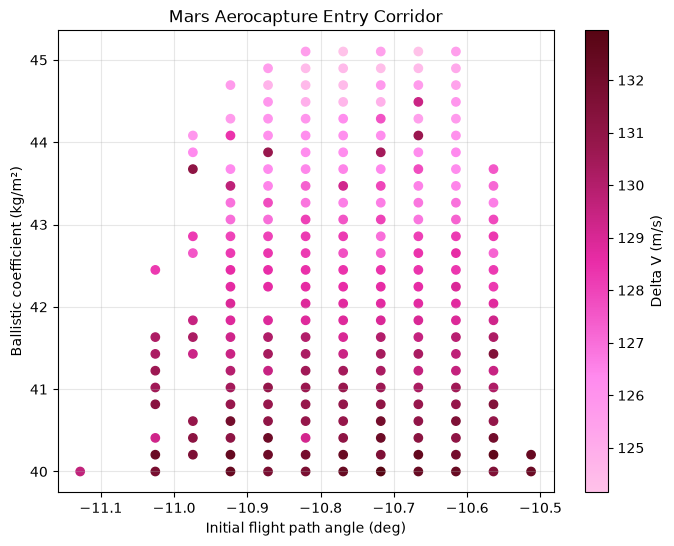

In [22]:
plt.figure(figsize=(8,6))
from matplotlib.colors import LinearSegmentedColormap

pink_red_map = LinearSegmentedColormap.from_list(
    "pink_red_map",
    [
        "#FFF0F5",   # very light pink (lavender blush)
        "#FFB6C1",   # light pink
        "#FF69B4",   # hot pink
        "#F0285A",   # deep pink
        "#B00020"    # dark red
    ]
)

newest_map = LinearSegmentedColormap.from_list(
    "newest_map",
    [
        "#FFC2E9",
        "#FF8AEE",
        "#E92CA7",
        "#98174D",
        "#570513"
    ]
)

plt.scatter(
    gammas,
    betas,
    c=delta_v,
    cmap=newest_map,
)


plt.colorbar(
    label="Delta V (m/s)"
)


plt.xlabel(
    "Initial flight path angle (deg)"
)


plt.ylabel(
    "Ballistic coefficient (kg/m²)"
)



plt.title(
    "Mars Aerocapture Entry Corridor"
)


plt.grid(alpha=0.3)

plt.show()

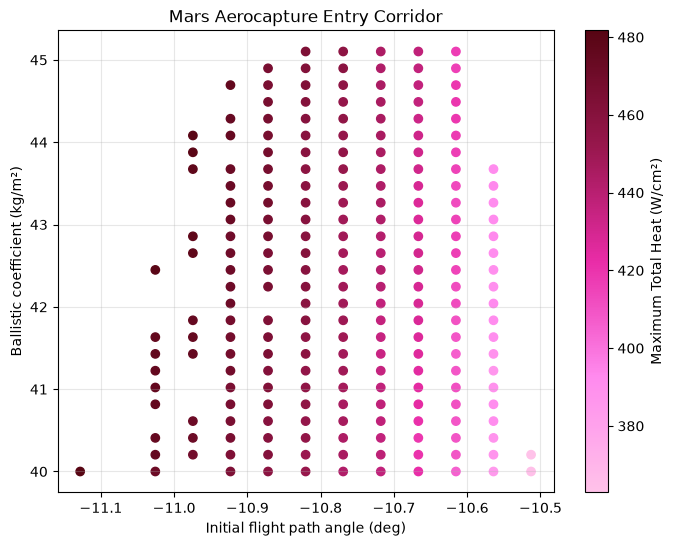

In [23]:
plt.figure(figsize=(8,6))

pink_red_map = LinearSegmentedColormap.from_list(
    "pink_red_map",
    [
        "#FFF0F5",   # very light pink (lavender blush)
        "#FFB6C1",   # light pink
        "#FF69B4",   # hot pink
        "#F0285A",   # deep pink
        "#B00020"    # dark red
    ]
)

newest_map = LinearSegmentedColormap.from_list(
    "newest_map",
    [
        "#FFC2E9",
        "#FF8AEE",
        "#E92CA7",
        "#98174D",
        "#570513"
    ]
)

plt.scatter(
    gammas,
    betas,
    c=total_heat_max,
    cmap=newest_map,
)


plt.colorbar(
    label="Maximum Total Heat (W/cm²)"
)


plt.xlabel(
    "Initial flight path angle (deg)"
)


plt.ylabel(
    "Ballistic coefficient (kg/m²)"
)



plt.title(
    "Mars Aerocapture Entry Corridor"
)


plt.grid(alpha=0.3)

plt.show()

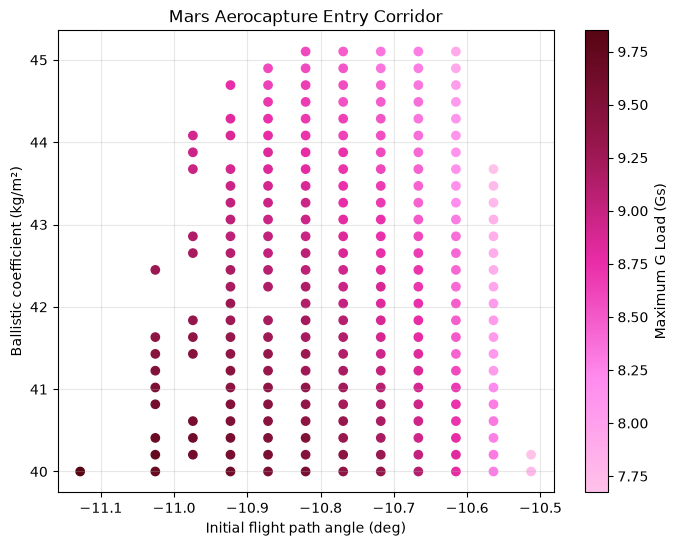

In [24]:
plt.figure(figsize=(8,6))

pink_red_map = LinearSegmentedColormap.from_list(
    "pink_red_map",
    [
        "#FFF0F5",   # very light pink (lavender blush)
        "#FFB6C1",   # light pink
        "#FF69B4",   # hot pink
        "#F0285A",   # deep pink
        "#B00020"    # dark red
    ]
)

newest_map = LinearSegmentedColormap.from_list(
    "newest_map",
    [
        "#FFC2E9",
        "#FF8AEE",
        "#E92CA7",
        "#98174D",
        "#570513"
    ]
)

plt.scatter(
    gammas,
    betas,
    c=g_load_max,
    cmap=newest_map,
)


plt.colorbar(
    label="Maximum G Load (Gs)"
)


plt.xlabel(
    "Initial flight path angle (deg)"
)


plt.ylabel(
    "Ballistic coefficient (kg/m²)"
)



plt.title(
    "Mars Aerocapture Entry Corridor"
)


plt.grid(alpha=0.3)

plt.show()

In [4]:
df = pd.DataFrame(results)

corridor = df.groupby("beta")["gamma"].agg(["min","max"]).reset_index()

plt.figure(figsize=(8,6))

plt.fill_between(
    corridor["beta"],
    corridor["min"],
    corridor["max"],
    alpha=0.4,
    label="Successful Corridor",
    color = "pink"
)

plt.plot(corridor["beta"], corridor["min"], 'k')
plt.plot(corridor["beta"], corridor["max"], 'k')

plt.xlabel("Ballistic Coefficient (kg/m²)")
plt.ylabel("Entry Flight Path Angle (deg)")
plt.title("Mars Aerocapture Entry Corridor")

plt.grid(True)
plt.legend()

NameError: name 'results' is not defined

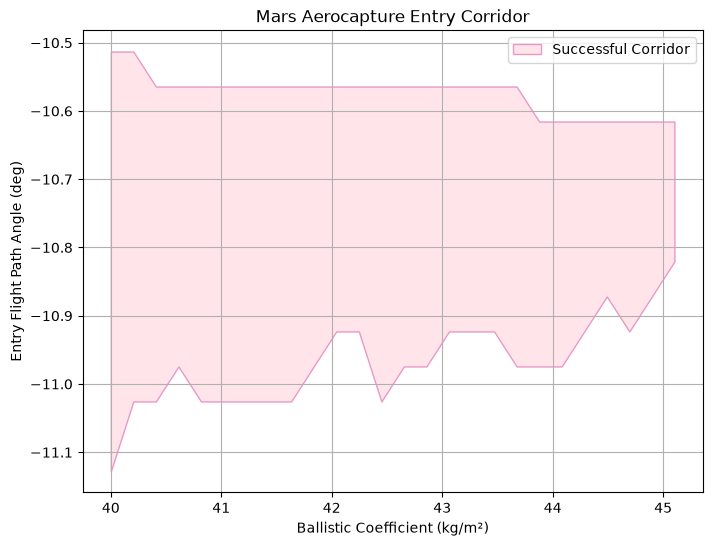

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the saved results
df = pd.read_csv("successful_cases_with_heat.csv")

# Create the corridor
corridor = df.groupby("beta")["gamma"].agg(["min", "max"]).reset_index()

# Plot
plt.figure(figsize=(8,6))

plt.fill_between(
    corridor["beta"],
    corridor["min"],
    corridor["max"],
    alpha=0.4,
    color="pink",
    label="Successful Corridor",
    edgecolor = "mediumvioletred"
)

plt.xlabel("Ballistic Coefficient (kg/m²)")
plt.ylabel("Entry Flight Path Angle (deg)")
plt.title("Mars Aerocapture Entry Corridor")

plt.grid(True)
plt.legend()
plt.show()

In [18]:
print(results)

          beta      gamma       apoapsis     delta_v  exit_velocity  \
0    40.000000 -10.512821  500000.113157  132.273609    3526.880283   
1    40.000000 -10.564103  499999.974195  131.574861    3527.283334   
2    40.000000 -10.615385  499999.945487  132.376262    3526.660004   
3    40.000000 -10.666667  499999.940259  132.393026    3526.627924   
4    40.000000 -10.717949  499999.934161  132.944951    3526.375295   
..         ...        ...            ...         ...            ...   
213  45.102041 -10.615385  499999.849610  125.540147    3532.581551   
214  45.102041 -10.666667  499999.769672  124.161186    3533.714443   
215  45.102041 -10.717949  499999.818851  125.467708    3532.753333   
216  45.102041 -10.769231  500000.061283  124.148449    3533.752528   
217  45.102041 -10.820513  500000.012292  125.559181    3532.503681   

                                       convective_heat  \
0    [0.0, 2.3847143040829795, 3.4624446292804554, ...   
1    [0.0, 2.3893320074296907, 

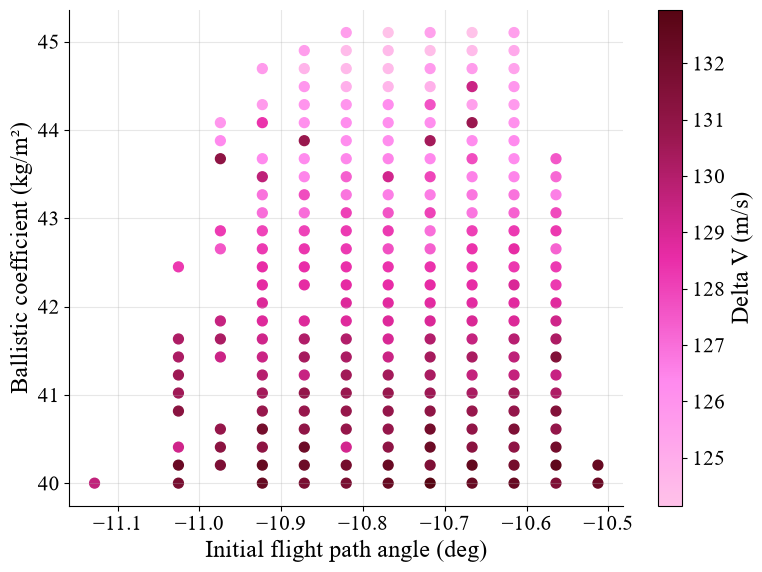

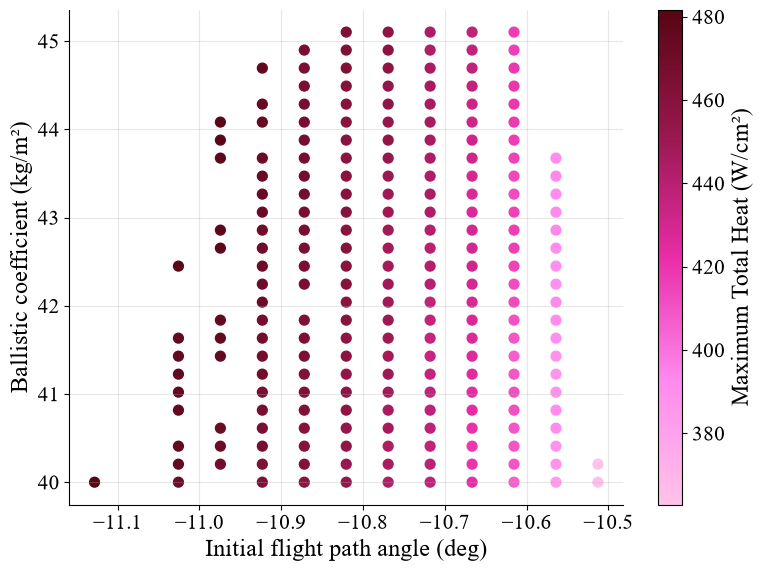

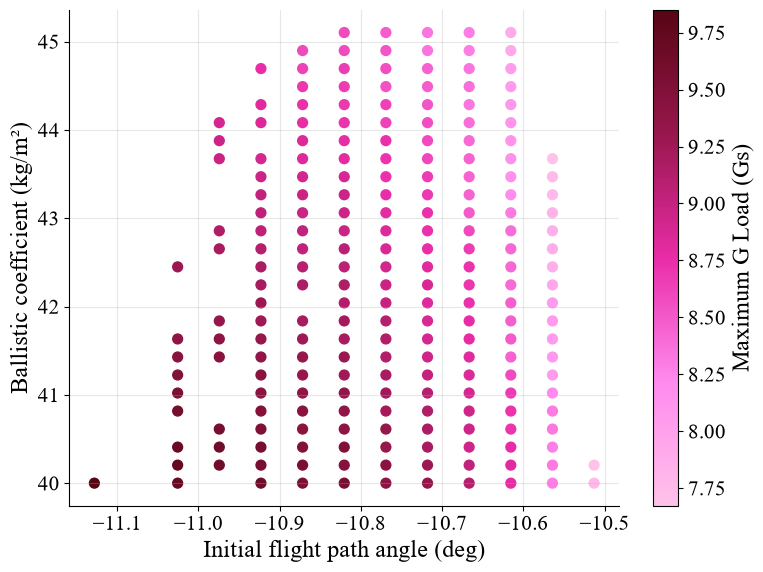

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


# ============================================================
# Font settings
# ============================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})


# ============================================================
# Load CSV
# ============================================================

df = pd.read_csv("successful_cases_with_heat_gamma.csv")


# ============================================================
# Convert stored arrays and extract maximum values
# ============================================================

def extract_max(array_string):
    """
    Converts numpy-style string arrays from CSV:
    '[0.0 0.001 0.002 ...]'
    into a numpy array and returns the maximum value.
    """

    array_string = array_string.strip("[]")

    values = np.fromstring(
        array_string,
        sep=" "
    )

    return np.max(values)



# Maximum g-load
df["g_load_max"] = df["g_load"].apply(extract_max)


# Maximum total heat
df["total_heat_max"] = df["total_heat"].apply(extract_max)



# ============================================================
# Extract plotting variables
# ============================================================

gammas = df["gamma"]
betas = df["beta"]

delta_v = df["delta_v"]
total_heat_max = df["total_heat_max"]
g_load_max = df["g_load_max"]



# ============================================================
# Colormap
# ============================================================

newest_map = LinearSegmentedColormap.from_list(
    "newest_map",
    [
        "#FFC2E9",
        "#FF8AEE",
        "#E92CA7",
        "#98174D",
        "#570513"
    ]
)



# ============================================================
# Plot function
# ============================================================

def make_corridor_plot(color_data, color_label):

    fig, ax = plt.subplots(
        figsize=(8,6)
    )


    scatter = ax.scatter(
        gammas,
        betas,
        c=color_data,
        cmap=newest_map,
        s=50
    )


    # Colorbar
    cbar = plt.colorbar(scatter)

    cbar.set_label(
        color_label
    )


    # Labels
    ax.set_xlabel(
        "Initial flight path angle (deg)"
    )

    ax.set_ylabel(
        "Ballistic coefficient (kg/m²)"
    )



    # Remove top/right border
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    # Tick style
    ax.tick_params(
        direction="out"
    )


    # Grid
    ax.grid(
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()



# ============================================================
# Plot 1: Delta V
# ============================================================

make_corridor_plot(
    delta_v,
    "Delta V (m/s)"
)



# ============================================================
# Plot 2: Maximum Total Heat
# ============================================================

make_corridor_plot(
    total_heat_max,
    "Maximum Total Heat (W/cm²)"
)



# ============================================================
# Plot 3: Maximum G-load
# ============================================================

make_corridor_plot(
    g_load_max,
    "Maximum G Load (Gs)"
)